 # Artificial Intelligence Technology and Application

 ## Machine Learning Lab Guide - Student Version

 # Part 1: Flower Category Analysis

 ## 1.1 Introduction

 This experiment uses the Iris dataset for a simple classification problem.

 ## 1.2 Experiment Code

 ### 1.2.1 Importing Related Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


 ### 1.2.2 Importing a Dataset

 The dataset is built-in in sklearn.

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

print(f"Dataset size: X shape: {X.shape}, y shape: {y.shape}")


Dataset size: X shape: (150, 4), y shape: (150,)


 ### 1.2.3 Splitting the Dataset

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("\nData size before splitting:", X.shape)
print("Data size after splitting (Train):", X_train.shape)
print("Data size after splitting (Test):", X_test.shape)



Data size before splitting: (150, 4)
Data size after splitting (Train): (112, 4)
Data size after splitting (Test): (38, 4)


 ### 1.2.4 Performing Modeling

The accuracy of the Logistic Regression is: 1.0
SVM: 1.0
The accuracy of the Decision Tree is: 1.0
The accuracy of the KNN is: 1.0
neighbor: 1, acc: 1.0
neighbor: 2, acc: 1.0
neighbor: 3, acc: 1.0
neighbor: 4, acc: 1.0
neighbor: 5, acc: 1.0
neighbor: 6, acc: 1.0
neighbor: 7, acc: 1.0
neighbor: 8, acc: 1.0
neighbor: 9, acc: 1.0
neighbor: 10, acc: 1.0


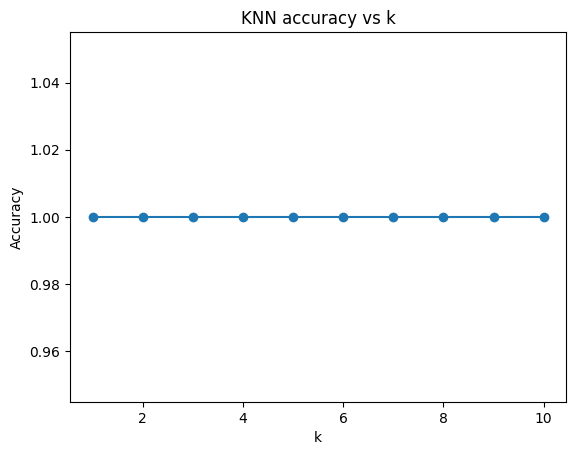

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print("The accuracy of the Logistic Regression is:", accuracy_score(y_test, lr.predict(X_test)))

# SVM
svm = SVC()
svm.fit(X_train, y_train)
print("SVM:", accuracy_score(y_test, svm.predict(X_test)))

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print("The accuracy of the Decision Tree is:", accuracy_score(y_test, dt.predict(X_test)))

# KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
print("The accuracy of the KNN is:", accuracy_score(y_test, knn.predict(X_test)))

# Recursion to find optimal number of neighbors
k_range = range(1, 11)
acc_scores = []

for k in k_range:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn_model.predict(X_test))
    acc_scores.append(acc)
    print(f"neighbor: {k}, acc: {acc}")

plt.plot(k_range, acc_scores, marker='o')
plt.title("KNN accuracy vs k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.show()


 ### 1.2.5 Effect After Data Preprocessing

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFirst row of X_test before scaling:", X_test[0])
print("First row of X_test after scaling:", X_test_scaled[0])

svm_scaled = SVC()
svm_scaled.fit(X_train_scaled, y_train)
print("\nSVM Accuracy after scaling:", accuracy_score(y_test, svm_scaled.predict(X_test_scaled)))



First row of X_test before scaling: [6.1 2.8 4.7 1.2]
First row of X_test after scaling: [ 0.33066442 -0.55192639  0.51683569 -0.01918559]

SVM Accuracy after scaling: 1.0


 # Part 2: Emotion Recognition of Customer Evaluations in the Retail Industry

 ## 2.1 Introduction

 Emotion analysis classification based on natural language processing (NLP).

 ## 2.2 Procedure

 ### 2.2.1 Data Management & 2.2.2 Data Reading

 Since we lack the original retail review dataset, we generate a small replica dataset mimicking it.

Shape of original dataset: (10, 4)

Missing values:
 reviews.rating      1
reviews.text        0
reviews.title       0
reviews.username    0
dtype: int64

Shape after dropping nan ratings: (9, 4)


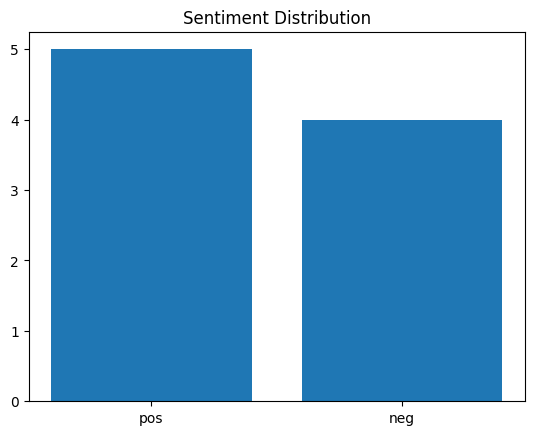

In [6]:
import pandas as pd
import numpy as np
import re
import string

# Mimic retail reviews dataset
df = pd.DataFrame({
    'reviews.rating': [1.0, 5.0, 4.0, 2.0, 5.0, 3.0, 4.0, 1.0, np.nan, 5.0],
    'reviews.text': [
        "disappointed, battery died in one week",
        "great for beginner or experienced person bought",
        "inexpensive tablet for him to use and learn on",
        "charger broke very fast... nope",
        "I've had my fire hd two weeks now and I love",
        "okay, ordinary item, nothing surprised.",
        "huge screen, nice experience but slightly bent",
        "terrible customer service and bad product",
        "will not buy again", # nan rating
        "this amazon fire 8 inch tablet is the perfect size!"
    ],
    'reviews.title': ["Bad", "Great", "Good value", "Broke", "Love it", "Ok", "Nice", "Terrible", "Nah", "Perfect"],
    'reviews.username': ["user1", "user2", "user3", "user4", "user5", "user6", "user7", "user8", "user9", "user10"]
})

print("Shape of original dataset:", df.shape)

# View missing values
print("\nMissing values:\n", df.isnull().sum())

# Drop nan ratings
senti = df.dropna(subset=['reviews.rating']).copy()
check = df[df['reviews.rating'].isnull()].copy()
print("\nShape after dropping nan ratings:", senti.shape)

# Convert ratings to pos/neg
senti['senti'] = np.where(senti['reviews.rating'] >= 4, 'pos', 'neg')

plt.bar(senti['senti'].value_counts().index, senti['senti'].value_counts().values)
plt.title("Sentiment Distribution")
plt.show()


 ### 2.2.3 Data Processing

In [7]:
# Clean up function
def cleanup(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

senti['Summary_Clean'] = senti['reviews.text'].apply(cleanup)
check['Summary_Clean'] = check['reviews.text'].apply(cleanup)

print("\nCleaned text sample:")
print(senti[['Summary_Clean', 'senti']].head())

# Train test split
split = senti[['Summary_Clean', 'senti']].copy()
# For demonstration with 9 samples, split size is small.
train = split.sample(frac=0.8, random_state=42)
test = split.drop(train.index)

print("\nSize of train:", train.shape)
print("Size of test:", test.shape)



Cleaned text sample:
                                     Summary_Clean senti
0            disappointed battery died in one week   neg
1  great for beginner or experienced person bought   pos
2   inexpensive tablet for him to use and learn on   pos
3                     charger broke very fast nope   neg
4      ive had my fire hd two weeks now and i love   pos

Size of train: (7, 2)
Size of test: (2, 2)


 ### 2.2.4 Model Training

In [8]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression

# Convert words to TF matrix and IDF
vectorizer = CountVectorizer()
X_train_counts = vectorizer.fit_transform(train['Summary_Clean'])
X_test_counts = vectorizer.transform(test['Summary_Clean'])
X_check_counts = vectorizer.transform(check['Summary_Clean'])

tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)
X_test_tfidf = tfidf_transformer.transform(X_test_counts)
check_tfidf = tfidf_transformer.transform(X_check_counts)

# MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train_tfidf, train['senti'])
print("\nMultinomial Accuracy:", accuracy_score(test['senti'], mnb.predict(X_test_tfidf)))

# BernoulliNB
bnb = BernoulliNB()
bnb.fit(X_train_tfidf, train['senti'])
print("Bernoulli Accuracy:", accuracy_score(test['senti'], bnb.predict(X_test_tfidf)))

# Logistic Regression
lr_nlp = LogisticRegression()
lr_nlp.fit(X_train_tfidf, train['senti'])
print("Logistic Regression Accuracy:", accuracy_score(test['senti'], lr_nlp.predict(X_test_tfidf)))

# Verify model
predictions = lr_nlp.predict_proba(check_tfidf)
print("\nPredicted probabilities for Check dataset:")
for pred in predictions:
    print(f"Sample estimated - negative prob {pred[0]:.6f}, positive prob {pred[1]:.6f}")

# Wordcloud
try:
    from wordcloud import WordCloud, STOPWORDS
    text_data = ' '.join(train['Summary_Clean'])
    wordcloud = WordCloud(stopwords=STOPWORDS, background_color='white', width=800, height=400).generate(text_data)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Word Cloud")
    plt.show()
except ImportError:
    print("\nWordCloud module is not installed. To see the wordcloud visualization, run: pip install wordcloud")



Multinomial Accuracy: 0.5
Bernoulli Accuracy: 0.5
Logistic Regression Accuracy: 0.5

Predicted probabilities for Check dataset:
Sample estimated - negative prob 0.433010, positive prob 0.566990

WordCloud module is not installed. To see the wordcloud visualization, run: pip install wordcloud
